### Supervised Machine Learning Using sklearn 

The models built in this notebook will predict **customer churn** (binary classification: `0` = stays, `1` = leaves) using four scikit-learn models. Each model gets its own section with a step-by-step explanation of what it does internally.

**Pre-requisite:** `01b_data_splitting_scaling_smote.ipynb` must be run first. This notebook loads the pre-processed splits it produced.

### The four models

| # | Model | Core idea |
|---|---|---|
| 1 | **Logistic Regression** | Linear weights + sigmoid gives probability |
| 2 | **Decision Tree** | Greedy if-else rules on features |
| 3 | **Random Forest** | 300 trees on bootstrap samples, averaged |
| 4 | **Gradient Boosting** | Sequential trees that fix previous errors |

### What goes through each model
Every customer is **38 feature values** (scaled continuous + binary/ordinal flags).

In [7]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    log_loss,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SPLITS_DIR = PROJECT_ROOT / 'data' / 'processed' / 'splits'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print('Splits dir:', SPLITS_DIR)
print('Models dir:', MODELS_DIR)

Splits dir: C:\Users\Ahana\Desktop\telco-churn-ml-lab\data\processed\splits
Models dir: C:\Users\Ahana\Desktop\telco-churn-ml-lab\models


In [8]:
# Load pre-processed splits (output of 01b_data_splitting_scaling_smote)
X_train = pd.read_csv(SPLITS_DIR / 'X_train_scaled.csv')
X_test  = pd.read_csv(SPLITS_DIR / 'X_test_scaled.csv')
y_train = pd.read_csv(SPLITS_DIR / 'y_train_resampled.csv').squeeze()
y_test  = pd.read_csv(SPLITS_DIR / 'y_test.csv').squeeze()

print('=' * 60)
print('  Loaded pre-processed splits')
print('=' * 60)
print(f'  X_train : {X_train.shape}  (SMOTE-balanced, scaled)')
print(f'  y_train : {y_train.shape}  churn rate = {y_train.mean():.1%}  <- 50/50 after SMOTE')
print(f'  X_test  : {X_test.shape}  (real-world distribution, scaled)')
print(f'  y_test  : {y_test.shape}  churn rate = {y_test.mean():.1%}  <- original 26.6%')
print(f'\n  {len(X_train.columns)} features: {list(X_train.columns)}')

  Loaded pre-processed splits
  X_train : (8260, 38)  (SMOTE-balanced, scaled)
  y_train : (8260,)  churn rate = 50.0%  <- 50/50 after SMOTE
  X_test  : (1407, 38)  (real-world distribution, scaled)
  y_test  : (1407,)  churn rate = 26.6%  <- original 26.6%

  38 features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charges_to_avg_ratio', 'log_monthly_charges', 'log_total_charges', 'tenure_group_encoded', 'num_add_on_services', 'has_protective_services', 'has_streaming', 'is_month_to_month', 'is_electronic_check', 'is_auto_payment', 'senior_alone', 'early_tenure', 'high_risk_combo', 'contract_encoded', 'internet_dsl', 'internet_fiber_optic', 'internet_no', 'payment_bank_transfer_automatic', 'payment_credit_card_automatic', 'payment_electronic_check', 'payment

### Background: Supervised Learning 

### The task
The labelled examples consisting of rows where `Churn` is known. The goal: learn `f(X)` such that `f(new_customer)` predicts whether they will leave.

```
X (38 features)  ->  f(X)  ->  P(churn) in [0,1]  ->  threshold 0.5  ->  {0, 1}
```

All four models learn a *different* `f`, but they all share the same interface: `predict_proba()` returns a probability, `predict()` returns a class.

### Reading the evaluation metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **Precision** (churn) | TP / (TP + FP) | Of everyone predicted to churn, what fraction actually did? |
| **Recall** (churn) | TP / (TP + FN) | Of everyone who actually churned, what fraction did we catch? |
| **F1** | 2*P*R / (P+R) | Harmonic mean of precision and recall |
| **ROC-AUC** | Area under ROC | Probability the model ranks a real churner above a non-churner |
| **Avg Precision** | Area under P-R curve | Better than ROC-AUC when classes are imbalanced |

```
> **For churn, recall matters more.** Missing a churner (False Negative) = lost customer. Falsely flagging a loyal customer (False Positive) = one unnecessary retention offer.
```

In [9]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, compute predictions, print report, return results dictionary."""
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    roc_auc  = roc_auc_score(y_te, y_prob)
    avg_prec = average_precision_score(y_te, y_prob)
    report   = classification_report(
        y_te, y_pred,
        target_names=['Retained', 'Churned'],
        output_dict=True
    )

    print(f'\n{chr(9472)*55}')
    print(f'  {name}')
    print(f'{chr(9472)*55}')
    print(classification_report(y_te, y_pred, target_names=['Retained', 'Churned']))
    print(f'  ROC-AUC       : {roc_auc:.4f}')
    print(f'  Avg Precision : {avg_prec:.4f}  (area under Precision-Recall curve)')

    return {
        'name'      : name,
        'model'     : model,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'roc_auc'   : roc_auc,
        'avg_prec'  : avg_prec,
        'precision' : report['Churned']['precision'],
        'recall'    : report['Churned']['recall'],
        'f1'        : report['Churned']['f1-score'],
        'report'    : report,
    }

results = {}
print('evaluate_model helper ready. results dictionary initialised.')

evaluate_model helper ready. results dictionary initialised.


### Model 1: Logistic Regression

### What is Logistic Regression? 
A **linear model** that maps features to a probability using the sigmoid function. It learns one weight per feature and one bias term.

### The math
```
log( P(churn) / P(stay) )  =  w1*f1 + w2*f2 + ... + w38*f38 + b
```
Applying sigmoid inverts this to a probability:
```
P(churn | X)  =  sigmoid(w*X + b)  =  1 / (1 + exp(-(w*X + b)))
```

### What flows through the model
```
Input row (38 numbers)
  |
  v
Dot product with learned weights  -->  scalar score  (any real number)
  |
  v
Sigmoid function  -->  probability between 0 and 1
  |
  v
Threshold at 0.5  -->  class 0 (Retained) or 1 (Churned)
```

### How the weights are learned (training)
- **Loss function:** binary cross-entropy (log-loss) -- penalises confident wrong predictions
- **Optimiser:** L-BFGS iteratively adjusts all 38 weights + bias to reduce log-loss
- **Regularisation:** L2 penalty (controlled by `C`) shrinks weights toward zero -- prevents over-relying on one feature

### Key hyperparameters

| Parameter | Role | Our value |
|---|---|---|
| `C` | Inverse regularisation strength. Lower = more regularised, smaller weights | `1.0` (default) |
| `max_iter` | Max gradient steps | `1000` |
| `solver` | Optimisation algorithm | `lbfgs` |

### Why LR needs scaled features
The L2 penalty is applied equally to all weights. If `TotalCharges` (range 0-8684) is unscaled, its weight would be tiny while `tenure` (range 1-72) gets a larger weight and thus the penalty would be unfair. StandardScaler fixes this.

In [10]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression', lr,
    X_train, y_train, X_test, y_test
)


───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.87      0.79      0.83      1033
     Churned       0.54      0.68      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407

  ROC-AUC       : 0.8273
  Avg Precision : 0.6275  (area under Precision-Recall curve)


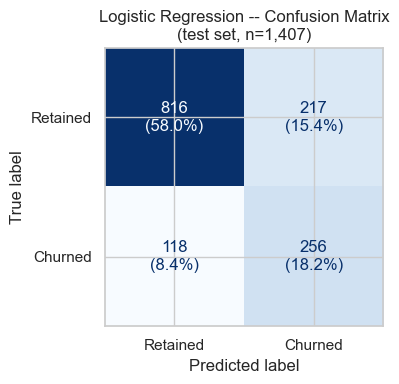

True Positives  (caught churners)         : 256
False Negatives (missed churners)         : 118  <- this is needed to be low to avoid losing customers
False Positives (wrongly flagged as churn): 217
True Negatives  (correctly kept)          : 816


In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    results['Logistic Regression']['y_pred'],
    display_labels=['Retained', 'Churned'],
    cmap='Blues', colorbar=False, ax=ax
)
total = len(y_test)
for text in ax.texts:
    val = int(text.get_text())
    text.set_text(f'{val}\n({val/total:.1%})')
ax.set_title('Logistic Regression -- Confusion Matrix\n(test set, n=1,407)')
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, results['Logistic Regression']['y_pred'])
TN, FP, FN, TP = cm.ravel()
print(f'True Positives  (caught churners)         : {TP}')
print(f'False Negatives (missed churners)         : {FN}  <- this is needed to be low to avoid losing customers')
print(f'False Positives (wrongly flagged as churn): {FP}')
print(f'True Negatives  (correctly kept)          : {TN}')

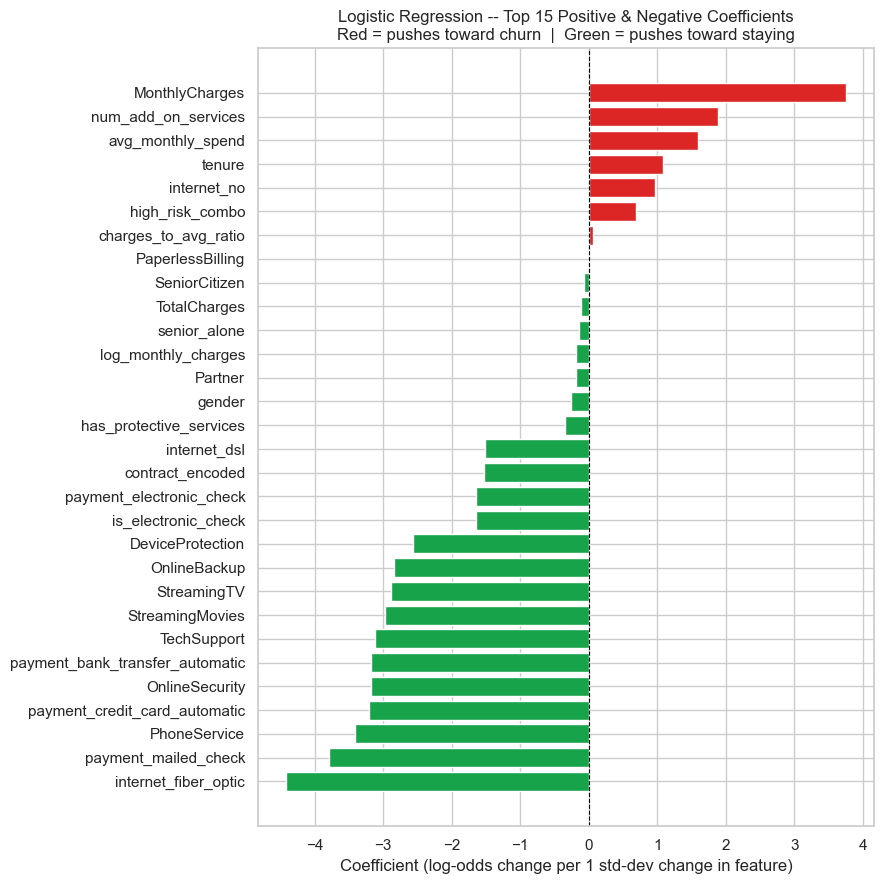

Top 5 features pushing TOWARD churn:
  internet_no                               +0.9660
  tenure                                    +1.0883
  avg_monthly_spend                         +1.5946
  num_add_on_services                       +1.8801
  MonthlyCharges                            +3.7563

Top 5 features pushing AWAY from churn:
  internet_fiber_optic                      -4.4127
  payment_mailed_check                      -3.7839
  PhoneService                              -3.4074
  payment_credit_card_automatic             -3.2061
  OnlineSecurity                            -3.1756


In [12]:
coef = results['Logistic Regression']['model'].coef_[0]
coef_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': coef})
coef_df = coef_df.sort_values('coefficient')

top_n = 15
plot_df = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)])
colors = ['#dc2626' if c > 0 else '#16a34a' for c in plot_df['coefficient']]

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    'Logistic Regression -- Top 15 Positive & Negative Coefficients\n'
    'Red = pushes toward churn  |  Green = pushes toward staying'
)
ax.set_xlabel('Coefficient (log-odds change per 1 std-dev change in feature)')
plt.tight_layout()
plt.show()

print('Top 5 features pushing TOWARD churn:')
for _, row in coef_df.tail(5).iterrows():
    print(f'  {row["feature"]:40s}  {row["coefficient"]:+.4f}')
print('\nTop 5 features pushing AWAY from churn:')
for _, row in coef_df.head(5).iterrows():
    print(f'  {row["feature"]:40s}  {row["coefficient"]:+.4f}')

### What happened inside the Logistic Regression Model above: 

1. **8,260 training rows** (50/50 balanced via SMOTE) went in
2. The model initialised all 38 weights near zero
3. For every row it computed `P(churn) = sigmoid(w*x + b)` and compared to the true label using log-loss
4. L-BFGS adjusted every weight in the direction that reduced log-loss - over many iterations
5. Training stopped when the gradient was small enough (convergence)

**Reading the coefficients:**
- A **positive coefficient** on `is_month_to_month` means that being month-to-month increases the log-odds of churn by that amount, holding everything else constant
- A **negative coefficient** on `tenure` means longer-tenured customers are less likely to churn
- Since all features are scaled to mean=0, std=1, coefficient sizes are directly comparable

**The linear limitation:** LR draws one straight hyperplane in 38-dimensional space. Complex interactions like "short tenure AND fiber optic AND month-to-month" are only partially captured.

### Model 2: Decision Tree

### What it is?
A **hierarchical sequence of binary rules**. Each internal node tests one feature against a threshold. Then decision makers follow left (yes) or right (no) until reaching a leaf, which predicts a class.

Example path a customer might follow:
```
Root: tenure < -0.71?  (roughly < 15 months scaled)
  YES --> contract_encoded < 0.5?  (month-to-month?)
            YES --> MonthlyCharges > 0.5?  (high bill?)
                      YES --> LEAF: Predict CHURN  (82% of samples here churned)
```

### What flows through the model
```
Input row (38 numbers)
  |
  v
Root: Feature[k] < threshold ?  YES/NO
  |
  v
Child node: Feature[j] < threshold ?  YES/NO
  |
  v  (repeat until leaf)
  |
  v
Leaf: majority class = prediction
      class fraction  = P(churn)
```

### How the tree is built (training)
At every node, try ALL (feature, threshold) combinations and pick the split that most reduces **Gini impurity**:
```
Gini(node) = 1 - sum(p_i^2)          lower = purer = better
Gain = Gini(parent) - weighted_avg(Gini(left), Gini(right))
```
Best split = maximum Gain. Then recurse on left and right children.

### The overfitting problem
An unlimited tree grows until every leaf is pure -- it memorises training data. This is **high variance**: small changes in training data can produce a completely different tree. We control this with `max_depth`.

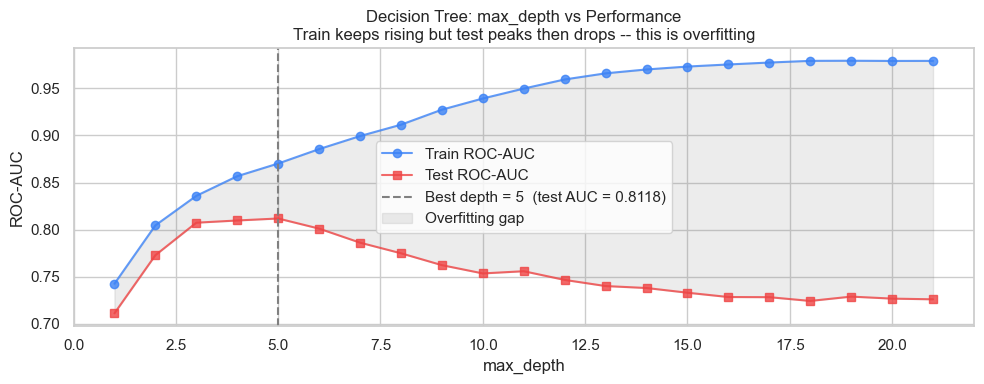

Best depth   : 5
Test  AUC at best depth: 0.8118
Train AUC at best depth: 0.8701


In [13]:
# Show how max_depth affects train vs test performance
depths = list(range(1, 22))
train_aucs, test_aucs = [], []

for d in depths:
    dt_tmp = DecisionTreeClassifier(max_depth=d, min_samples_leaf=5, random_state=RANDOM_STATE)
    dt_tmp.fit(X_train, y_train)
    train_aucs.append(roc_auc_score(y_train, dt_tmp.predict_proba(X_train)[:, 1]))
    test_aucs.append(roc_auc_score(y_test,   dt_tmp.predict_proba(X_test)[:, 1]))

best_depth = depths[int(np.argmax(test_aucs))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(depths, train_aucs, 'o-', label='Train ROC-AUC', color='#3b82f6', alpha=0.8)
ax.plot(depths, test_aucs,  's-', label='Test ROC-AUC',  color='#ef4444', alpha=0.8)
ax.axvline(best_depth, color='gray', linestyle='--',
           label=f'Best depth = {best_depth}  (test AUC = {max(test_aucs):.4f})')
ax.fill_between(depths,
    [min(tr, te) for tr, te in zip(train_aucs, test_aucs)],
    [max(tr, te) for tr, te in zip(train_aucs, test_aucs)],
    alpha=0.15, color='gray', label='Overfitting gap')
ax.set_xlabel('max_depth')
ax.set_ylabel('ROC-AUC')
ax.set_title('Decision Tree: max_depth vs Performance\nTrain keeps rising but test peaks then drops -- this is overfitting')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best depth   : {best_depth}')
print(f'Test  AUC at best depth: {test_aucs[best_depth-1]:.4f}')
print(f'Train AUC at best depth: {train_aucs[best_depth-1]:.4f}')

In [14]:
dt = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)
results['Decision Tree'] = evaluate_model(
    'Decision Tree', dt,
    X_train, y_train, X_test, y_test
)
print(f'\n  Tree depth  : {results["Decision Tree"]["model"].get_depth()}')
print(f'  Leaf nodes  : {results["Decision Tree"]["model"].get_n_leaves()}')


───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.90      0.73      0.80      1033
     Churned       0.50      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407

  ROC-AUC       : 0.8118
  Avg Precision : 0.5682  (area under Precision-Recall curve)

  Tree depth  : 5
  Leaf nodes  : 31


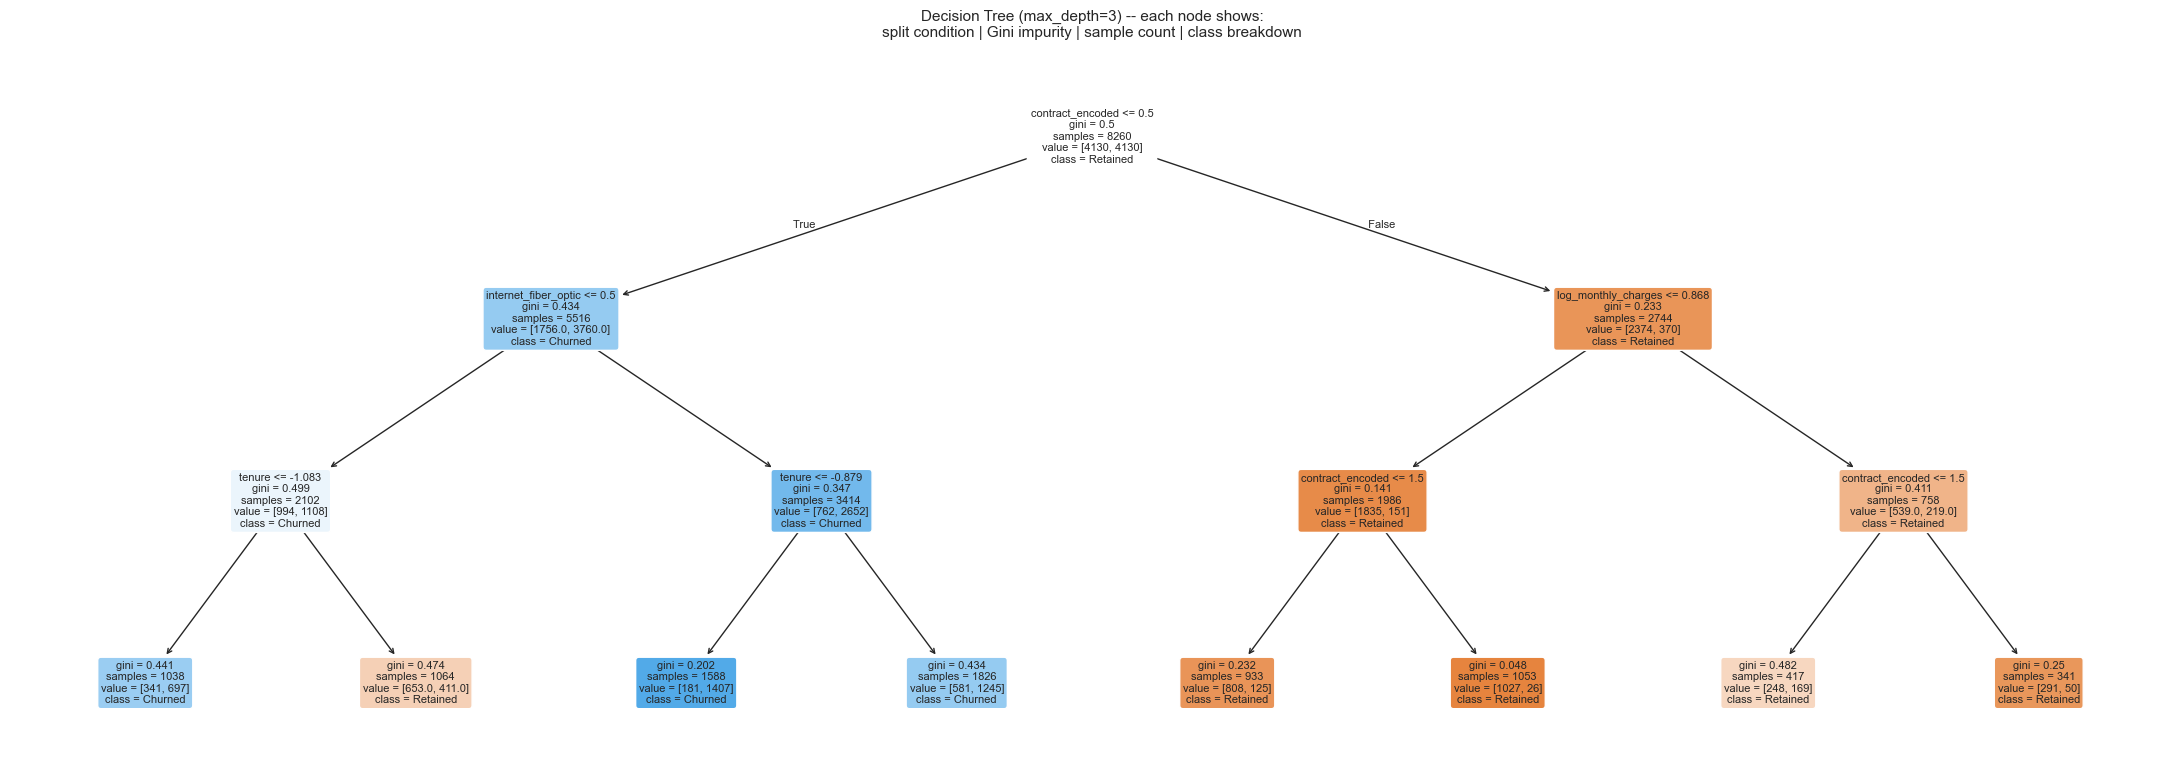

First 3 levels as text rules:
|--- contract_encoded <= 0.50
|   |--- internet_fiber_optic <= 0.50
|   |   |--- tenure <= -1.08
|   |   |   |--- class: 1
|   |   |--- tenure >  -1.08
|   |   |   |--- class: 0
|   |--- internet_fiber_optic >  0.50
|   |   |--- tenure <= -0.88
|   |   |   |--- class: 1
|   |   |--- tenure >  -0.88
|   |   |   |--- class: 1
|--- contract_encoded >  0.50
|   |--- log_monthly_charges <= 0.87
|   |   |--- contract_encoded <= 1.50
|   |   |   |--- class: 0
|   |   |--- contract_encoded >  1.50
|   |   |   |--- class: 0
|   |--- log_monthly_charges >  0.87
|   |   |--- contract_encoded <= 1.50
|   |   |   |--- class: 0
|   |   |--- contract_encoded >  1.50
|   |   |   |--- class: 0



In [15]:
# Visualise a depth-3 slice so we can read the actual rules
dt_vis = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=RANDOM_STATE)
dt_vis.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_vis,
    feature_names=X_train.columns.tolist(),
    class_names=['Retained', 'Churned'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    impurity=True, proportion=False,
)
ax.set_title(
    'Decision Tree (max_depth=3) -- each node shows:\n'
    'split condition | Gini impurity | sample count | class breakdown',
    fontsize=11
)
plt.tight_layout()
plt.show()

print('First 3 levels as text rules:')
print(export_text(dt_vis, feature_names=X_train.columns.tolist(), max_depth=3))

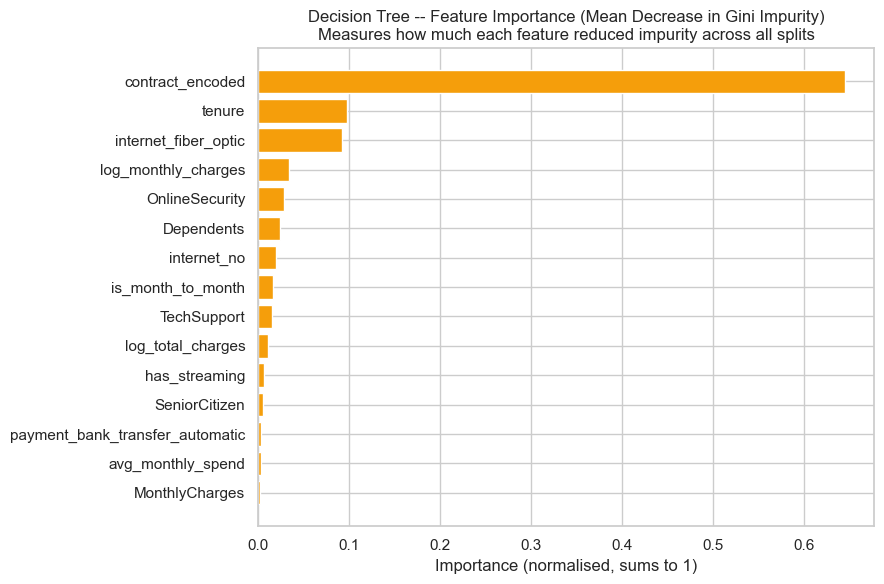

In [16]:
feat_imp_dt = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': results['Decision Tree']['model'].feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp_dt['feature'], feat_imp_dt['importance'], color='#f59e0b', edgecolor='white')
ax.set_title(
    'Decision Tree -- Feature Importance (Mean Decrease in Gini Impurity)\n'
    'Measures how much each feature reduced impurity across all splits'
)
ax.set_xlabel('Importance (normalised, sums to 1)')
plt.tight_layout()
plt.show()

### What happened inside the Decision Tree: 

1. **Root split:** the algorithm evaluated every possible (feature, threshold) pair across all 38 features and ~8,260 unique values each -- millions of candidate splits -- and picked the one giving the biggest Gini gain
2. Each child node repeated this process recursively -- greedy, locally optimal at each step
3. Growth stopped when `max_depth` was reached or a node had fewer than `min_samples_leaf` samples
4. At inference: each test row travels down the tree, one comparison per node, until it hits a leaf. The leaf's class distribution becomes the probability

**The depth scan shows two failure modes:**
- Depth 1: one rule -- too simple, misses complex patterns (underfitting)
- Depth > best: memorises training noise -- test AUC drops even as train AUC keeps rising (overfitting)

**Feature importance = total Gini reduction.** A feature used near the root (on many samples) gets more credit than one used only in deep, narrow branches.

**The core problem with a single tree:** it has high variance. Grow it on a slightly different sample and you get a very different tree. 

### Model 3: Random Forest

### What is a Random Forest Model?
An **ensemble** of decision trees, each trained on a different random bootstrap sample. Predictions are averaged across all trees.

### What flows through the model (inference)
```
Input row (38 features)
  |
  +-->  Tree   1  -->  P(churn) = 0.72
  +-->  Tree   2  -->  P(churn) = 0.61
  +-->  Tree   3  -->  P(churn) = 0.78
  |         ...
  +-->  Tree 300  -->  P(churn) = 0.69
                 |
                 v
         Average = 0.70  -->  Predict CHURN
```

### The two sources of randomness (training)

**1. Bootstrap sampling (Bagging)**
Each tree trains on a random sample *with replacement* of the training data -- same row count, ~63% unique rows. The remaining ~37% of rows are the tree's **Out-of-Bag (OOB)** set, which gives a free built-in validation estimate.

**2. Random feature subsets at each split**
At every node in every tree, only `sqrt(38) ~= 6` randomly selected features are considered. This **decorrelates** the trees -- even if one feature dominates, other trees will be forced to find complementary signals.

### Why averaging works
Each individual tree has high variance (overfit to its bootstrap sample). If we average N trees with variance sigma^2 and low correlation:
```
Variance(average) ~= sigma^2 / N
```
Variance drops proportionally to 1/N. Bias stays the same. This is the theoretical basis of bagging.

### Key hyperparameters

| Parameter | Role | Our value |
|---|---|---|
| `n_estimators` | Number of trees | 300 |
| `max_features` | Candidate features per split | `sqrt` (~6 of 38) |
| `min_samples_leaf` | Min samples per leaf | 2 |
| `oob_score` | Compute OOB accuracy during fit | True |

    5 trees  -->  OOB error = 0.2433
   10 trees  -->  OOB error = 0.1953
   20 trees  -->  OOB error = 0.1723
   30 trees  -->  OOB error = 0.1642
   50 trees  -->  OOB error = 0.1541
   75 trees  -->  OOB error = 0.1535
  100 trees  -->  OOB error = 0.1518
  150 trees  -->  OOB error = 0.1518
  200 trees  -->  OOB error = 0.1494
  250 trees  -->  OOB error = 0.1493
  300 trees  -->  OOB error = 0.1501


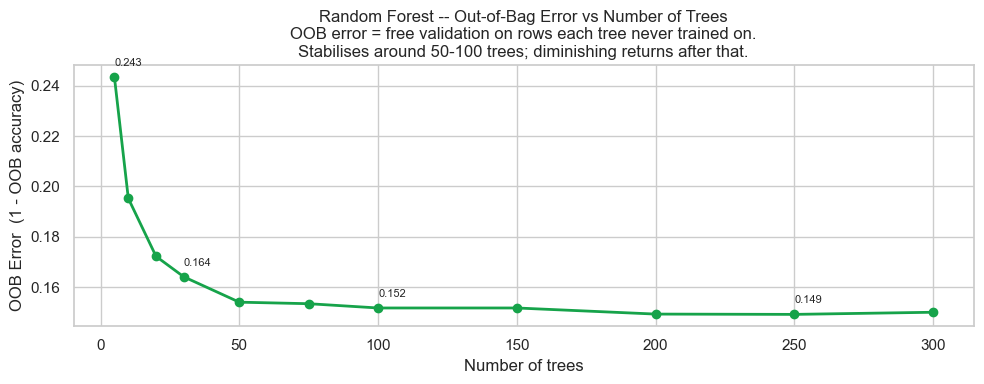

In [17]:
# Show OOB error converging as we add more trees
# warm_start=True lets us incrementally add trees instead of refitting from scratch
rf_oob = RandomForestClassifier(
    oob_score=True, warm_start=True,
    max_features='sqrt', min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)

n_checkpoints = [5, 10, 20, 30, 50, 75, 100, 150, 200, 250, 300]
oob_errors = []

for n in n_checkpoints:
    rf_oob.n_estimators = n
    rf_oob.fit(X_train, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)
    print(f'  {n:3d} trees  -->  OOB error = {oob_errors[-1]:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_checkpoints, oob_errors, 'o-', color='#16a34a', linewidth=2)
ax.set_xlabel('Number of trees')
ax.set_ylabel('OOB Error  (1 - OOB accuracy)')
ax.set_title(
    'Random Forest -- Out-of-Bag Error vs Number of Trees\n'
    'OOB error = free validation on rows each tree never trained on.\n'
    'Stabilises around 50-100 trees; diminishing returns after that.'
)
for n, e in zip(n_checkpoints[::3], oob_errors[::3]):
    ax.annotate(f'{e:.3f}', (n, e), textcoords='offset points', xytext=(0, 8), fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=2,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
results['Random Forest'] = evaluate_model(
    'Random Forest', rf,
    X_train, y_train, X_test, y_test
)
print(f'\n  OOB accuracy (free estimate, no test set used): {rf.oob_score_:.4f}')


───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.87      0.81      0.84      1033
     Churned       0.56      0.67      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407

  ROC-AUC       : 0.8187
  Avg Precision : 0.5861  (area under Precision-Recall curve)

  OOB accuracy (free estimate, no test set used): 0.8499


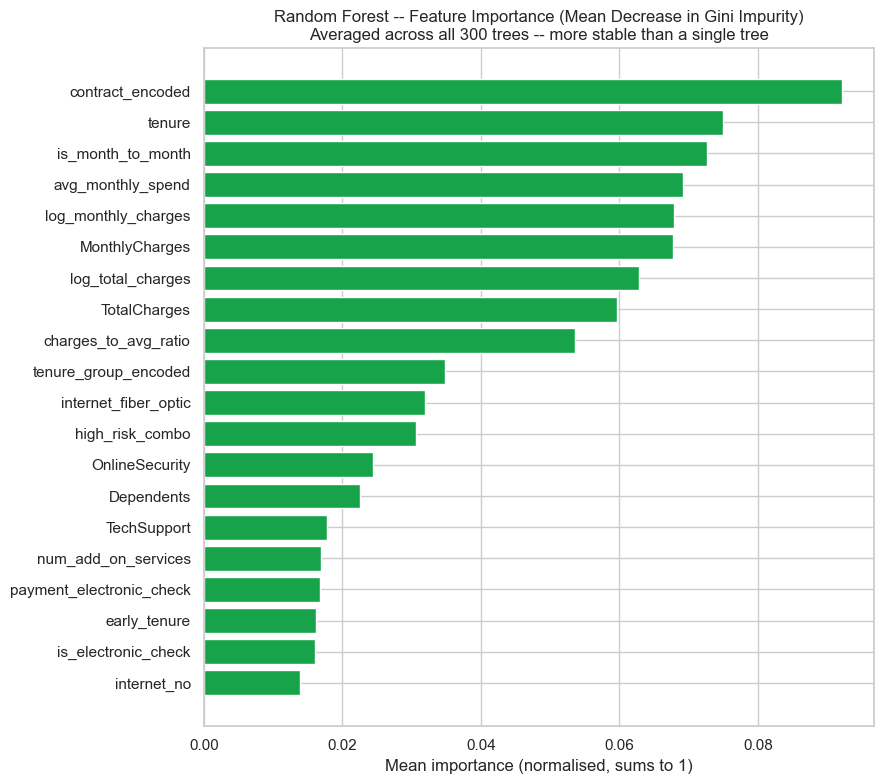

In [19]:
feat_imp_rf = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': results['Random Forest']['model'].feature_importances_
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(feat_imp_rf['feature'], feat_imp_rf['importance'], color='#16a34a', edgecolor='white')
ax.set_title(
    'Random Forest -- Feature Importance (Mean Decrease in Gini Impurity)\n'
    'Averaged across all 300 trees -- more stable than a single tree'
)
ax.set_xlabel('Mean importance (normalised, sums to 1)')
plt.tight_layout()
plt.show()

In [20]:
# Peek inside one individual tree from the forest
one_tree = results['Random Forest']['model'].estimators_[0]
print('Tree #0 from the 300-tree forest:')
print(f'  Depth        : {one_tree.get_depth()}  (fully grown -- no max_depth limit)')
print(f'  Leaf nodes   : {one_tree.get_n_leaves()}')
print(f'  ~Train rows  : {int(0.632 * len(X_train)):,}  (~63.2% unique in each bootstrap sample)')
print(f'  ~OOB rows    : {int(0.368 * len(X_train)):,}  (~36.8% never seen by this tree)')
print(f'\nFirst 2 levels of Tree #0:')
print(export_text(one_tree, feature_names=X_train.columns.tolist(), max_depth=2))

Tree #0 from the 300-tree forest:
  Depth        : 26  (fully grown -- no max_depth limit)
  Leaf nodes   : 967
  ~Train rows  : 5,220  (~63.2% unique in each bootstrap sample)
  ~OOB rows    : 3,039  (~36.8% never seen by this tree)

First 2 levels of Tree #0:
|--- is_month_to_month <= 0.50
|   |--- has_streaming <= 0.50
|   |   |--- MonthlyCharges <= 0.74
|   |   |   |--- truncated branch of depth 16
|   |   |--- MonthlyCharges >  0.74
|   |   |   |--- truncated branch of depth 4
|   |--- has_streaming >  0.50
|   |   |--- MonthlyCharges <= 1.14
|   |   |   |--- truncated branch of depth 15
|   |   |--- MonthlyCharges >  1.14
|   |   |   |--- truncated branch of depth 14
|--- is_month_to_month >  0.50
|   |--- MonthlyCharges <= 0.15
|   |   |--- payment_bank_transfer_automatic <= 0.50
|   |   |   |--- truncated branch of depth 24
|   |   |--- payment_bank_transfer_automatic >  0.50
|   |   |   |--- truncated branch of depth 9
|   |--- MonthlyCharges >  0.15
|   |   |--- TotalCharges 

### What happened inside the Random Forest Model: 

1. **300 bootstrap samples** were drawn from the 8,260 training rows (with replacement)
2. Each tree was built fully on its bootstrap sample -- no depth limit, so each tree overfits its sample
3. At every split in every tree, only ~6 randomly chosen features were candidates -- this decorrelates the trees
4. For each test row: the row passed through all 300 trees, each returned a probability, those were averaged
5. The **OOB score** used each tree's held-out ~37% rows for free validation -- no test set needed

**Why it beats a single tree:**
- Each individual tree overfits to its own bootstrap sample, but they overfit to *different noise*
- Averaging 300 partially uncorrelated noisy estimates: the noise cancels out, the signal compounds
- The OOB convergence chart showed the error floor - adding trees beyond ~100 gives very little gain

**Feature importance** is averaged across 300 trees, making it much more stable and reliable than a single decision tree's importance.

### Model 4: Gradient Boosting

### What it is?
An ensemble of trees built **sequentially** where each tree corrects the residual errors left by all previous trees - this is called **Boosting**. Unlike Random Forest (parallel, reduces variance), Gradient Boosting reduces **bias** step by step.

### What flows through the model (training)
```
Stage 0:  Initial prediction = log-odds of base rate
          e.g. log(0.5/0.5) = 0  (50/50 after SMOTE)

Stage 1:  residuals = true_labels - P(churn from stage 0)
          Train shallow Tree_1 to predict these residuals
          Update: score += learning_rate * Tree_1(X)

Stage 2:  residuals = true_labels - P(churn from stage 1)  <- smaller now
          Train shallow Tree_2 on updated residuals
          Update: score += learning_rate * Tree_2(X)

  ...

Stage 200:  score has converged  -->  sigmoid(score) = final P(churn)
```

### What flows through the model (inference)
```
Input row (38 features)
  |
  v
  Tree_1   output: +0.12
+ Tree_2   output: -0.04
+ Tree_3   output: +0.09
    ...
+ Tree_200 output: +0.02
  |
  v
Sum * learning_rate  -->  log-odds score
  |
  v
sigmoid(score)  -->  P(churn)  -->  class
```

### Key hyperparameters

| Parameter | Role | Our value |
|---|---|---|
| `n_estimators` | Number of boosting stages | 200 |
| `learning_rate` | Shrinks each tree's contribution | 0.05 |
| `max_depth` | Depth of each tree (shallow = better for boosting) | 3 |
| `subsample` | Fraction of rows per tree (adds regularisation) | 0.8 |
| `min_samples_leaf` | Min samples in any leaf | 10 |

### Boosting vs Bagging

| | Random Forest | Gradient Boosting |
|---|---|---|
| Trees built | **Parallel** (independent) | **Sequential** (each fixes last) |
| Reduces | Variance | Bias |
| Individual trees | Deep, high-variance | Shallow, weak learners |
| Overfit risk | Resistant | Can overfit if n_estimators too high |

**Why `learning_rate` matters:** A smaller rate (e.g. 0.01) means tiny steps per tree and requires more trees but less risk of overshooting the optimal fit. Larger rate = faster learning but there are possibilities of overfitting.

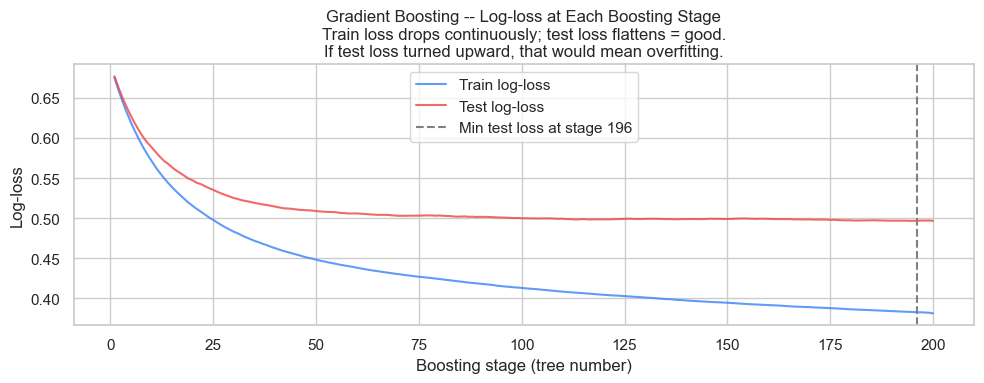

Stage 196: min test log-loss = 0.4967
Stage 196: train log-loss    = 0.3828
Stage 200 (final): train = 0.3813, test = 0.4968


In [21]:
# Train GB and watch staged log-loss to see the boosting learning curve
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
)
gb.fit(X_train, y_train)

# staged_predict_proba yields predictions at each boosting stage (1, 2, ..., 200)
train_loss = [log_loss(y_train, yp) for yp in gb.staged_predict_proba(X_train)]
test_loss  = [log_loss(y_test,  yp) for yp in gb.staged_predict_proba(X_test)]

best_stage = int(np.argmin(test_loss)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
stages = range(1, gb.n_estimators + 1)
ax.plot(stages, train_loss, label='Train log-loss', color='#3b82f6', alpha=0.8, linewidth=1.5)
ax.plot(stages, test_loss,  label='Test log-loss',  color='#ef4444', alpha=0.8, linewidth=1.5)
ax.axvline(best_stage, color='gray', linestyle='--', label=f'Min test loss at stage {best_stage}')
ax.set_xlabel('Boosting stage (tree number)')
ax.set_ylabel('Log-loss')
ax.set_title(
    'Gradient Boosting -- Log-loss at Each Boosting Stage\n'
    'Train loss drops continuously; test loss flattens = good.\n'
    'If test loss turned upward, that would mean overfitting.'
)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Stage {best_stage}: min test log-loss = {min(test_loss):.4f}')
print(f'Stage {best_stage}: train log-loss    = {train_loss[best_stage-1]:.4f}')
print(f'Stage 200 (final): train = {train_loss[-1]:.4f}, test = {test_loss[-1]:.4f}')

In [22]:
results['Gradient Boosting'] = evaluate_model(
    'Gradient Boosting', gb,
    X_train, y_train, X_test, y_test
)


───────────────────────────────────────────────────────
  Gradient Boosting
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.88      0.75      0.81      1033
     Churned       0.51      0.72      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.78      0.74      0.76      1407

  ROC-AUC       : 0.8227
  Avg Precision : 0.6184  (area under Precision-Recall curve)


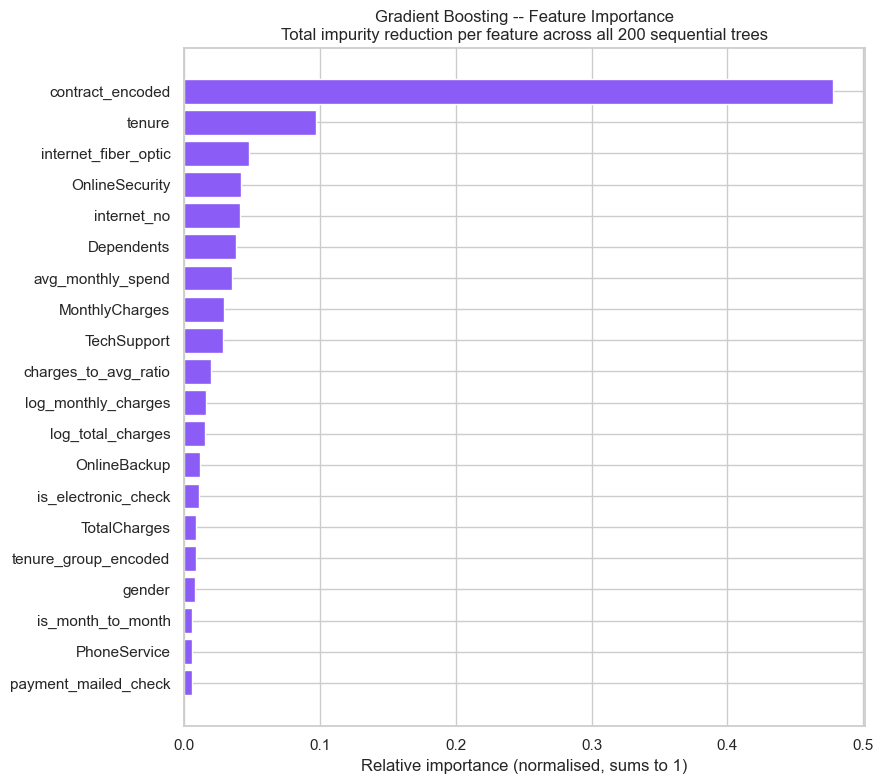

In [23]:
feat_imp_gb = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': results['Gradient Boosting']['model'].feature_importances_
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(feat_imp_gb['feature'], feat_imp_gb['importance'], color='#8b5cf6', edgecolor='white')
ax.set_title(
    'Gradient Boosting -- Feature Importance\n'
    'Total impurity reduction per feature across all 200 sequential trees'
)
ax.set_xlabel('Relative importance (normalised, sums to 1)')
plt.tight_layout()
plt.show()

### What happened inside the Gradient Boosting Model:

1. **Stage 0:** Initial prediction = log-odds of training churn rate (0.0 since SMOTE made it 50/50)
2. **Stages 1-200:** Each shallow tree (max_depth=3, at most 8 leaves) fitted to the pseudo-residuals -- the gradient of log-loss tells the model where it is most wrong
3. Each tree output was scaled by `learning_rate=0.05` before adding -- small, careful steps
4. `subsample=0.8` sampled 80% of rows per tree, introducing stochasticity that helps regularise
5. The staged loss plot shows log-loss dropping steadily -- the model improved with each stage

**Why shallow trees?** Each tree captures only a simple 2-3 level interaction. Stacking 200 of these builds complex non-linear patterns incrementally, while no single tree is complex enough to overfit alone.

**The `learning_rate` trade-off:** Smaller rate = more stages needed to converge, but each step is safer and more regularised. The combination `learning_rate=0.05, n_estimators=200` is a common starting point.

### Model Comparison:

All four models trained on the same 8,260-row SMOTE-balanced training set.  
Evaluated on the same 1,407-row test set (real-world churn distribution: 26.6%).

In [24]:
summary = pd.DataFrame([
    {
        'Model'             : name,
        'ROC-AUC'           : f"{r['roc_auc']:.4f}",
        'Avg Precision'     : f"{r['avg_prec']:.4f}",
        'Precision (churn)' : f"{r['precision']:.4f}",
        'Recall (churn)'    : f"{r['recall']:.4f}",
        'F1 (churn)'        : f"{r['f1']:.4f}",
    }
    for name, r in results.items()
]).set_index('Model')

print('=' * 80)
print('  MODEL COMPARISON -- Test Set (n=1,407, 26.6% churn rate)')
print('=' * 80)
print(summary.to_string())
print()

best_recall = max(results.items(), key=lambda x: x[1]['recall'])
best_auc    = max(results.items(), key=lambda x: x[1]['roc_auc'])
print(f'Best recall  : {best_recall[0]} ({best_recall[1]["recall"]:.4f}) <- most churners caught')
print(f'Best ROC-AUC : {best_auc[0]} ({best_auc[1]["roc_auc"]:.4f})')

  MODEL COMPARISON -- Test Set (n=1,407, 26.6% churn rate)
                    ROC-AUC Avg Precision Precision (churn) Recall (churn) F1 (churn)
Model                                                                                
Logistic Regression  0.8273        0.6275            0.5412         0.6845     0.6045
Decision Tree        0.8118        0.5682            0.5044         0.7674     0.6087
Random Forest        0.8187        0.5861            0.5558         0.6658     0.6058
Gradient Boosting    0.8227        0.6184            0.5123         0.7246     0.6002

Best recall  : Decision Tree (0.7674) <- most churners caught
Best ROC-AUC : Logistic Regression (0.8273)


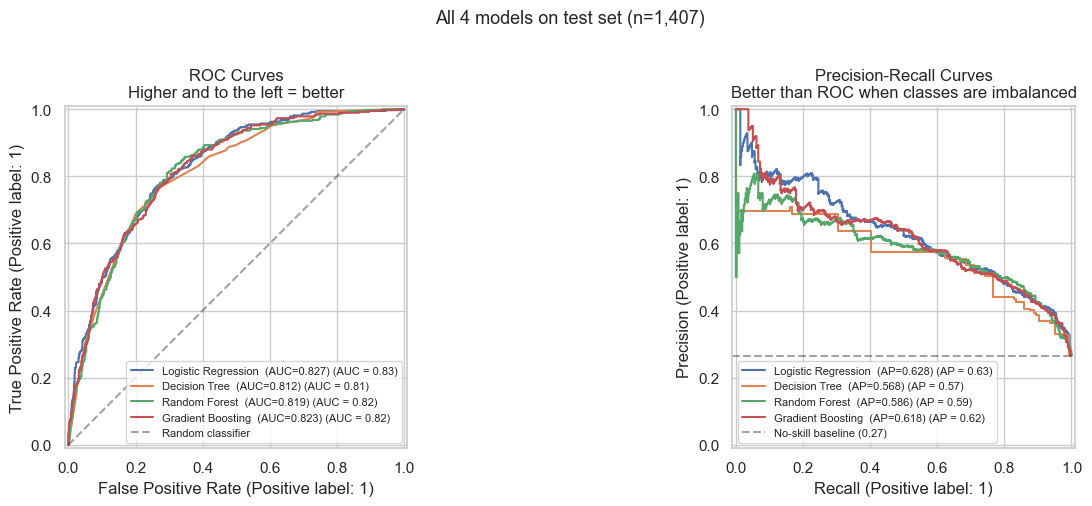

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in results.items():
    RocCurveDisplay.from_predictions(
        y_test, r['y_prob'],
        name=f"{name}  (AUC={r['roc_auc']:.3f})",
        ax=axes[0]
    )
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
axes[0].set_title('ROC Curves\nHigher and to the left = better')
axes[0].legend(fontsize=8)

for name, r in results.items():
    PrecisionRecallDisplay.from_predictions(
        y_test, r['y_prob'],
        name=f"{name}  (AP={r['avg_prec']:.3f})",
        ax=axes[1]
    )
base = y_test.mean()
axes[1].axhline(base, color='k', linestyle='--', alpha=0.4,
                label=f'No-skill baseline ({base:.2f})')
axes[1].set_title(
    'Precision-Recall Curves\n'
    'Better than ROC when classes are imbalanced'
)
axes[1].legend(fontsize=8)

plt.suptitle('All 4 models on test set (n=1,407)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

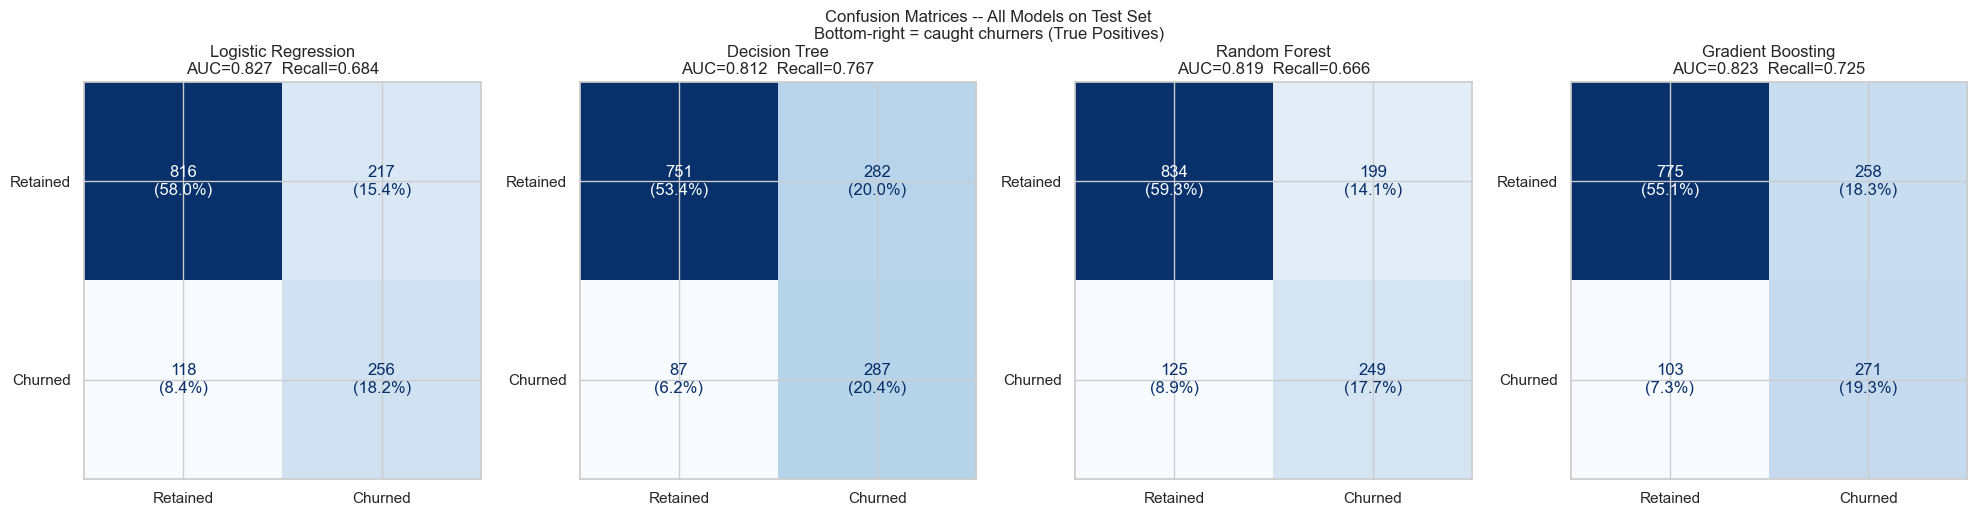

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
total = len(y_test)

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC={r["roc_auc"]:.3f}  Recall={r["recall"]:.3f}')
    for text, val in zip(ax.texts, cm.flatten()):
        text.set_text(f'{val}\n({val/total:.1%})')
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle(
    'Confusion Matrices -- All Models on Test Set\n'
    'Bottom-right = caught churners (True Positives)',
    fontsize=12
)
plt.tight_layout()
plt.show()

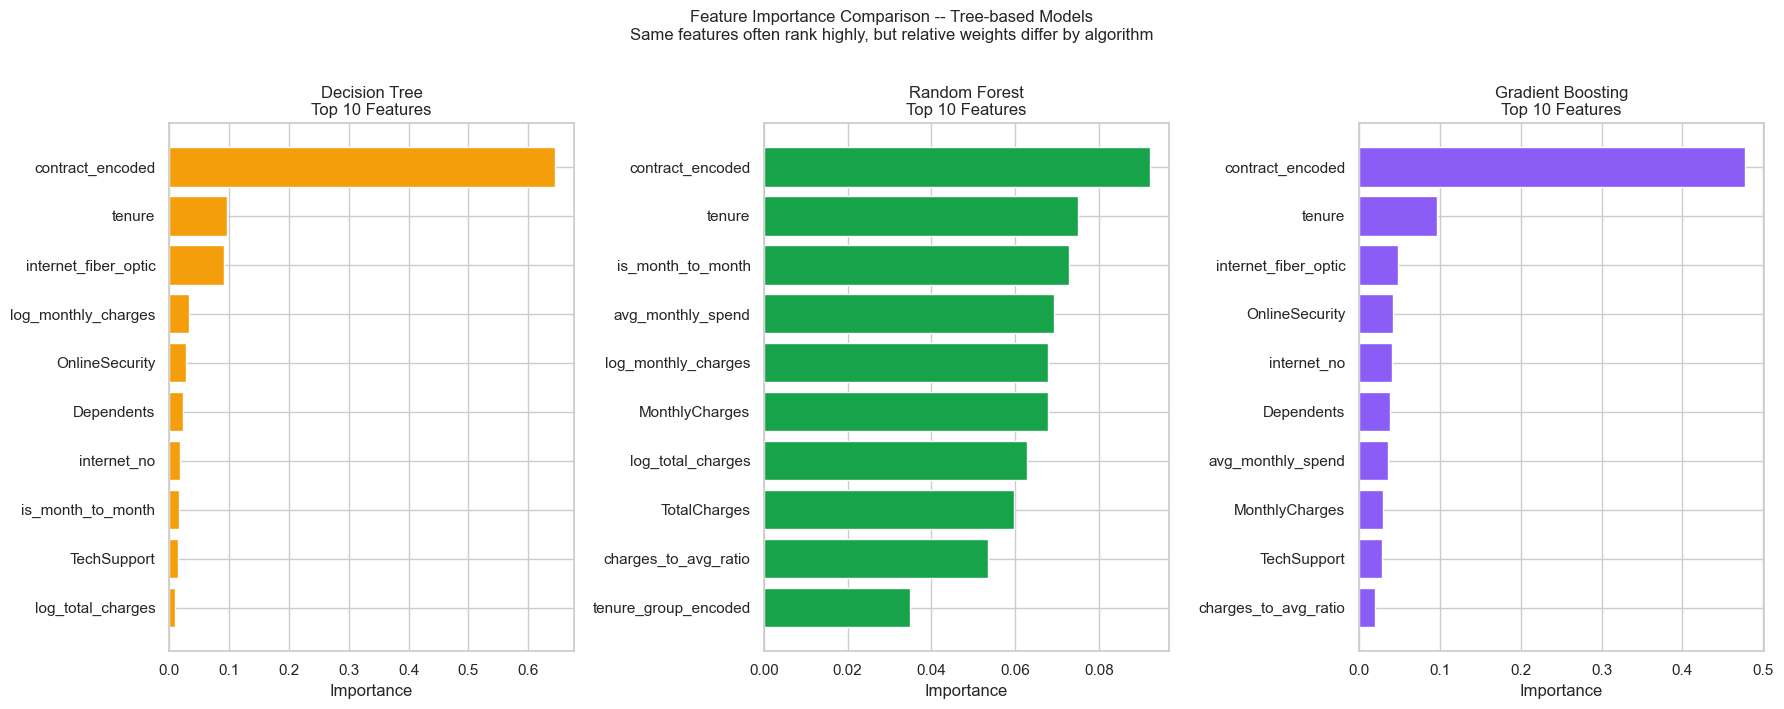

Note: Logistic Regression uses signed coefficients (not shown here).
      See the LR coefficient chart earlier in this notebook.


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

tree_models = [
    ('Decision Tree',     results['Decision Tree']['model'].feature_importances_,     '#f59e0b'),
    ('Random Forest',     results['Random Forest']['model'].feature_importances_,     '#16a34a'),
    ('Gradient Boosting', results['Gradient Boosting']['model'].feature_importances_, '#8b5cf6'),
]

for ax, (name, importances, color) in zip(axes, tree_models):
    df_imp = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
    df_imp = df_imp.sort_values('importance', ascending=True).tail(10)
    ax.barh(df_imp['feature'], df_imp['importance'], color=color, edgecolor='white')
    ax.set_title(f'{name}\nTop 10 Features')
    ax.set_xlabel('Importance')

plt.suptitle(
    'Feature Importance Comparison -- Tree-based Models\n'
    'Same features often rank highly, but relative weights differ by algorithm',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()
print('Note: Logistic Regression uses signed coefficients (not shown here).')
print('      See the LR coefficient chart earlier in this notebook.')

In [28]:
best_name   = max(results, key=lambda n: results[n]['roc_auc'])
best_result = results[best_name]

print(f'Best model by ROC-AUC: {best_name}  ({best_result["roc_auc"]:.4f})')

model_path = MODELS_DIR / 'best_churn_model.joblib'
joblib.dump(best_result['model'], model_path)
print(f'Saved model   : {model_path}')

metrics_to_save = {
    name: {
        'roc_auc'   : r['roc_auc'],
        'avg_prec'  : r['avg_prec'],
        'precision' : r['precision'],
        'recall'    : r['recall'],
        'f1'        : r['f1'],
    }
    for name, r in results.items()
}
metrics_path = MODELS_DIR / 'supervised_sklearn_metrics.json'
metrics_path.write_text(json.dumps(metrics_to_save, indent=2))
print(f'Saved metrics : {metrics_path}')
print()
print(json.dumps(metrics_to_save, indent=2))

Best model by ROC-AUC: Logistic Regression  (0.8273)
Saved model   : C:\Users\Ahana\Desktop\telco-churn-ml-lab\models\best_churn_model.joblib
Saved metrics : C:\Users\Ahana\Desktop\telco-churn-ml-lab\models\supervised_sklearn_metrics.json

{
  "Logistic Regression": {
    "roc_auc": 0.8272993875892343,
    "avg_prec": 0.6275164870381839,
    "precision": 0.5412262156448203,
    "recall": 0.6844919786096256,
    "f1": 0.6044864226682408
  },
  "Decision Tree": {
    "roc_auc": 0.8118402865854606,
    "avg_prec": 0.5682259523657893,
    "precision": 0.5043936731107206,
    "recall": 0.767379679144385,
    "f1": 0.6086956521739131
  },
  "Random Forest": {
    "roc_auc": 0.8187253780329347,
    "avg_prec": 0.5861326865301019,
    "precision": 0.5558035714285714,
    "recall": 0.6657754010695187,
    "f1": 0.6058394160583942
  },
  "Gradient Boosting": {
    "roc_auc": 0.8226597160029196,
    "avg_prec": 0.6184489280567238,
    "precision": 0.5122873345935728,
    "recall": 0.7245989304812

### Final Summary for the Supervised ML Training: 

### What each model does: 

| Model | Input | Core operation | Output |
|---|---|---|---|
| **Logistic Regression** | 38 scaled features | Dot product with weights + sigmoid | P(churn) from a linear boundary |
| **Decision Tree** | 38 features (any scale) | Routes through if-else rules to a leaf | P(churn) = leaf class fraction |
| **Random Forest** | 38 features (any scale) | Routes through 300 independent trees, averages | P(churn) = mean across all trees |
| **Gradient Boosting** | 38 features (any scale) | Sums 200 sequential residual-correcting trees | P(churn) = sigmoid of summed scores |

### Key insights
- **LR** needs scaled features. Its coefficients directly explain *which* features drive churn.
- **DT** is the most interpretable as we can literally read the rules, but overfits without a depth limit.
- **RF** beats a single tree by averaging 300 noisy-but-uncorrelated trees. OOB score is a free validation estimate.
- **GB** often gets the best AUC by iteratively correcting errors. The staged loss plot is a critical diagnostic: if test loss turns upward, you are overfitting.

### About SMOTE
All models trained on the SMOTE-balanced set (50/50). This boosted recall at the cost of some precision. The test set was never resampled -- metrics reflect real-world performance at 26.6% churn rate.